In [486]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [487]:
df = pd.read_csv('data/car.csv', index_col=0)
df

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0


Data Preprocessing

In [488]:
df[['Brand', 'Model']] = df['CarName'].str.split(' ', n=1, expand=True)
df = df.drop('CarName', axis=1)
df = df[['Brand', 'Model'] + [col for col in df.columns if col not in ['Brand', 'Model']]]
df['Model'] = df['Model'].str.split().str[0].fillna('unknown')
df

,Brand,Model,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,,,,,,,,,,,,,,,,,,,,,
1,alfa-romero,giulia,3,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,alfa-romero,stelvio,3,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,alfa-romero,Quadrifoglio,1,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,audi,100,2,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,audi,100ls,2,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,volvo,145e,-1,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
202,volvo,144ea,-1,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
203,volvo,244dl,-1,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0


In [489]:
df["Model"].values

array(['giulia', 'stelvio', 'Quadrifoglio', '100', '100ls', 'fox',
       '100ls', '5000', '4000', '5000s', '320i', '320i', 'x1', 'x3', 'z4',
       'x4', 'x5', 'x3', 'impala', 'monte', 'vega', 'rampage',
       'challenger', 'd200', 'monaco', 'colt', 'colt', 'coronet', 'dart',
       'coronet', 'civic', 'civic', 'civic', 'accord', 'civic', 'accord',
       'civic', 'accord', 'civic', 'prelude', 'accord', 'civic', 'civic',
       'MU-X', 'D-Max', 'D-Max', 'D-Max', 'xj', 'xf', 'xk', 'rx3', 'glc',
       'rx2', 'rx-4', 'glc', '626', 'glc', 'rx-7', 'glc', '626', 'glc',
       'glc', 'rx-4', 'glc', '626', 'glc', 'rx-7', 'electra', 'century',
       'century', 'skyhawk', 'opel', 'skylark', 'century', 'regal',
       'cougar', 'mirage', 'lancer', 'outlander', 'g4', 'mirage', 'g4',
       'outlander', 'g4', 'mirage', 'montero', 'pajero', 'outlander',
       'mirage', 'versa', 'gt-r', 'rogue', 'latio', 'titan', 'leaf',
       'juke', 'latio', 'note', 'clipper', 'rogue', 'nv200', 'dayz',
      

In [490]:
df.isnull().sum()

Brand               0
Model               0
symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [491]:
df["doornumber"] = df["doornumber"].replace({"two": 2, "four": 4})
df["fueltype"] = df["fueltype"].replace({"gas": 0, "diesel": 1})
df["aspiration"] = df["aspiration"].replace({"std": 0, "turbo": 1})
df["drivewheel"] = df["drivewheel"].replace({"fwd": 0, "rwd": 1, "4wd": 2})
df["enginelocation"] = df["enginelocation"].replace({"front": 0, "rear": 1})

In [492]:
X = df.drop("price", axis=1)
y = df["price"].values
X

,Brand,Model,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
car_ID,,,,,,,,,,,,,,,,,,,,,
1,alfa-romero,giulia,3,0,0,2,convertible,1,0,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,alfa-romero,stelvio,3,0,0,2,convertible,1,0,88.6,...,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27
3,alfa-romero,Quadrifoglio,1,0,0,2,hatchback,1,0,94.5,...,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26
4,audi,100,2,0,0,4,sedan,0,0,99.8,...,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30
5,audi,100ls,2,0,0,4,sedan,2,0,99.4,...,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,volvo,145e,-1,0,0,4,sedan,1,0,109.1,...,four,141,mpfi,3.78,3.15,9.5,114,5400,23,28
202,volvo,144ea,-1,0,1,4,sedan,1,0,109.1,...,four,141,mpfi,3.78,3.15,8.7,160,5300,19,25
203,volvo,244dl,-1,0,0,4,sedan,1,0,109.1,...,six,173,mpfi,3.58,2.87,8.8,134,5500,18,23


In [493]:
y

array([13495.   , 16500.   , 16500.   , 13950.   , 17450.   , 15250.   ,
       17710.   , 18920.   , 23875.   , 17859.167, 16430.   , 16925.   ,
       20970.   , 21105.   , 24565.   , 30760.   , 41315.   , 36880.   ,
        5151.   ,  6295.   ,  6575.   ,  5572.   ,  6377.   ,  7957.   ,
        6229.   ,  6692.   ,  7609.   ,  8558.   ,  8921.   , 12964.   ,
        6479.   ,  6855.   ,  5399.   ,  6529.   ,  7129.   ,  7295.   ,
        7295.   ,  7895.   ,  9095.   ,  8845.   , 10295.   , 12945.   ,
       10345.   ,  6785.   ,  8916.5  ,  8916.5  , 11048.   , 32250.   ,
       35550.   , 36000.   ,  5195.   ,  6095.   ,  6795.   ,  6695.   ,
        7395.   , 10945.   , 11845.   , 13645.   , 15645.   ,  8845.   ,
        8495.   , 10595.   , 10245.   , 10795.   , 11245.   , 18280.   ,
       18344.   , 25552.   , 28248.   , 28176.   , 31600.   , 34184.   ,
       35056.   , 40960.   , 45400.   , 16503.   ,  5389.   ,  6189.   ,
        6669.   ,  7689.   ,  9959.   ,  8499.   , 

In [494]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [495]:
ct = ColumnTransformer(transformers=[
    ("encoder", OneHotEncoder(), ["Brand", "Model", "carbody", "enginetype", "cylindernumber", "fuelsystem"])
], remainder="passthrough")

In [496]:
X = ct.fit_transform(X)

In [497]:
feature_names = ct.get_feature_names_out()
X_df = pd.DataFrame(X.toarray(), columns=feature_names)
X_df

,encoder__Brand_Nissan,encoder__Brand_alfa-romero,encoder__Brand_audi,encoder__Brand_bmw,encoder__Brand_buick,encoder__Brand_chevrolet,encoder__Brand_dodge,encoder__Brand_honda,encoder__Brand_isuzu,encoder__Brand_jaguar,...,remainder__carheight,remainder__curbweight,remainder__enginesize,remainder__boreratio,remainder__stroke,remainder__compressionratio,remainder__horsepower,remainder__peakrpm,remainder__citympg,remainder__highwaympg
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,48.8,2548.0,130.0,3.47,2.68,9.0,111.0,5000.0,21.0,27.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,52.4,2823.0,152.0,2.68,3.47,9.0,154.0,5000.0,19.0,26.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,54.3,2337.0,109.0,3.19,3.40,10.0,102.0,5500.0,24.0,30.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,54.3,2824.0,136.0,3.19,3.40,8.0,115.0,5500.0,18.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.5,2952.0,141.0,3.78,3.15,9.5,114.0,5400.0,23.0,28.0
201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.5,3049.0,141.0,3.78,3.15,8.7,160.0,5300.0,19.0,25.0
202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.5,3012.0,173.0,3.58,2.87,8.8,134.0,5500.0,18.0,23.0
203,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.5,3217.0,145.0,3.01,3.40,23.0,106.0,4800.0,26.0,27.0


In [498]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42)

In [499]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [500]:
X_train

array([[-0.07832604, -0.13650473, -0.19487094, ..., -1.91782869,
         0.96431609,  1.3135007 ],
       [-0.07832604, -0.13650473, -0.19487094, ..., -0.292907  ,
        -0.98812636, -1.02456857],
       [-0.07832604, -0.13650473, -0.19487094, ..., -0.69913742,
         0.96431609,  1.00175813],
       ...,
       [-0.07832604, -0.13650473, -0.19487094, ...,  0.11332343,
         0.96431609,  1.00175813],
       [-0.07832604, -0.13650473, -0.19487094, ...,  0.11332343,
        -0.98812636, -1.02456857],
       [-0.07832604, -0.13650473, -0.19487094, ...,  0.11332343,
        -1.31353343, -1.33631113]], shape=(164, 189))

Model Training and Evaluation

In [501]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from xgboost import XGBRegressor

regressor = XGBRegressor(random_state=42)

parametrers = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
}

grid = GridSearchCV(
    estimator=regressor,
    param_grid=parametrers,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
0.9037246613423982


In [502]:
regressor = grid.best_estimator_

In [503]:
from sklearn.metrics import r2_score, mean_absolute_error

In [504]:
y_train_pred = regressor.predict(X_train)

y_pred = regressor.predict(X_test)

Visualization

In [505]:
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Train R²: {r2_train:.2f}")
print(f"Test R²: {r2:.2f}")
print(f"Train MAE: {mae_train:.2f}")
print(f"Test MAE: {mae:.2f}")

Train R²: 0.99
Test R²: 0.93
Train MAE: 562.42
Test MAE: 1700.71


In [506]:
cv_scores = cross_val_score(regressor, X_train, y_train, cv=5, scoring='r2')
print(cv_scores)
print(cv_scores.mean())

[0.91501088 0.93676855 0.80634783 0.95595772 0.90453832]
0.9037246613423982


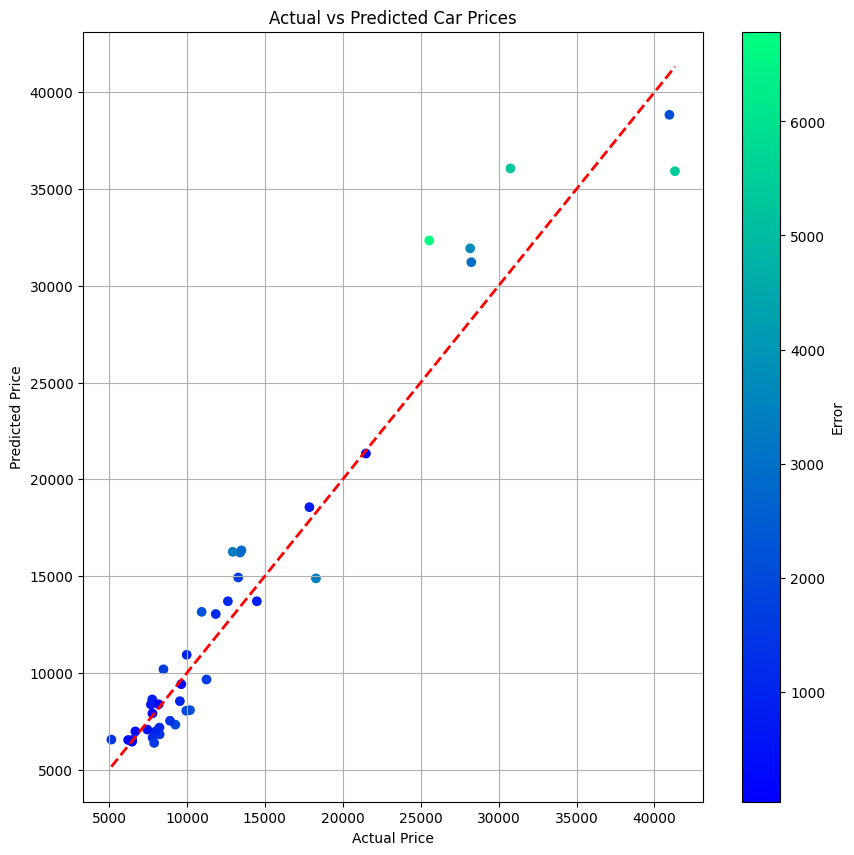

In [523]:
plt.figure(figsize=(10,10))

error = np.abs(y_test - y_pred)
plt.scatter(y_test, y_pred, c=error, cmap='winter')
plt.colorbar(label="Error")

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.grid(True)

plt.show()